# Handwritten Character Recognition


CNN-based recognizer for handwritten digits (MNIST) and letters/digits (EMNIST), built with TensorFlow/Keras.



## **Setup: install & import libraries**

In [1]:
!pip install -q emnist

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## C**hoose your dataset**

Set `DATASET = "mnist"` for digits (0-9, easiest, ~99% accuracy) or `DATASET = "emnist"` for digits + letters (47 classes, harder, ~88-90% accuracy).

In [2]:
DATASET = "mnist"          # "mnist" or "emnist"
EMNIST_SPLIT = "balanced"  # only used if DATASET == "emnist"
EPOCHS = 15
BATCH_SIZE = 128
USE_AUGMENTATION = False   # set True for emnist to help generalization
OUT_DIR = "outputs"
MODEL_PATH = "handwriting_cnn.keras"

os.makedirs(OUT_DIR, exist_ok=True)

## **Load the dataset**

In [3]:
def load_mnist():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    class_names = [str(i) for i in range(10)]
    return (x_train, y_train), (x_test, y_test), class_names


def load_emnist(split="balanced"):
    from emnist import extract_training_samples, extract_test_samples

    x_train, y_train = extract_training_samples(split)
    x_test, y_test = extract_test_samples(split)

    if split == "balanced":
        mapping = list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt")
        class_names = mapping[: len(set(y_train))]
    elif split == "letters":
        class_names = list("abcdefghijklmnopqrstuvwxyz")
    else:
        class_names = [str(i) for i in sorted(set(y_train))]

    return (x_train, y_train), (x_test, y_test), class_names


print(f"Loading {DATASET} dataset...")
if DATASET == "mnist":
    (x_train, y_train), (x_test, y_test), class_names = load_mnist()
else:
    (x_train, y_train), (x_test, y_test), class_names = load_emnist(EMNIST_SPLIT)

num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")
print(f"Train samples: {len(x_train)}, Test samples: {len(x_test)}")

Loading mnist dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Classes (10): ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train samples: 60000, Test samples: 10000


## **Data OverView**

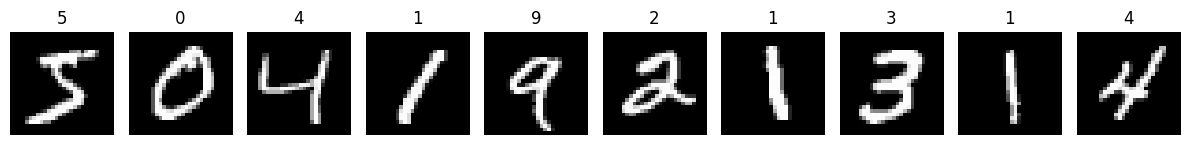

In [4]:
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## **Preprocess: normalize, reshape, one-hot encode**

In [5]:
def preprocess(x_train, y_train, x_test, y_test, num_classes):
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    x_train = np.expand_dims(x_train, -1)
    x_test = np.expand_dims(x_test, -1)

    y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
    y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

    return x_train, y_train_cat, x_test, y_test_cat


x_train_p, y_train_cat, x_test_p, y_test_cat = preprocess(
    x_train, y_train, x_test, y_test, num_classes
)
print("x_train shape:", x_train_p.shape)
print("y_train_cat shape:", y_train_cat.shape)

x_train shape: (60000, 28, 28, 1)
y_train_cat shape: (60000, 10)


## **Build the CNN model**

In [6]:
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_cnn(input_shape=x_train_p.shape[1:], num_classes=num_classes)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

### **Data augmentation**

Helps generalization, especially useful for EMNIST. Only used if `USE_AUGMENTATION = True`.

In [7]:
def get_augmenter():
    return tf.keras.preprocessing.image.ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
    )


if USE_AUGMENTATION:
    augmenter = get_augmenter()
    augmenter.fit(x_train_p)
    print("Augmentation enabled.")
else:
    augmenter = None
    print("Augmentation disabled.")

Augmentation disabled.


## **Train the model**

In [8]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
)

if USE_AUGMENTATION:
    history = model.fit(
        augmenter.flow(x_train_p, y_train_cat, batch_size=BATCH_SIZE),
        validation_data=(x_test_p, y_test_cat),
        epochs=EPOCHS,
        callbacks=[early_stop, reduce_lr],
    )
else:
    history = model.fit(
        x_train_p, y_train_cat,
        validation_data=(x_test_p, y_test_cat),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[early_stop, reduce_lr],
    )

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.9445 - loss: 0.1821 - val_accuracy: 0.5836 - val_loss: 1.1326 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9800 - loss: 0.0653 - val_accuracy: 0.9904 - val_loss: 0.0297 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9850 - loss: 0.0485 - val_accuracy: 0.9913 - val_loss: 0.0260 - learning_rate: 0.0010
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9877 - loss: 0.0394 - val_accuracy: 0.9914 - val_loss: 0.0266 - learning_rate: 0.0010
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9895 - loss: 0.0350 - val_accuracy: 0.9911 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9913 - loss: 0.0276 - val_accuracy: 0.9941 - val_loss: 0.0176 - learning_rate: 5.0000e-04
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9929 - loss:

### **Plot training curves**

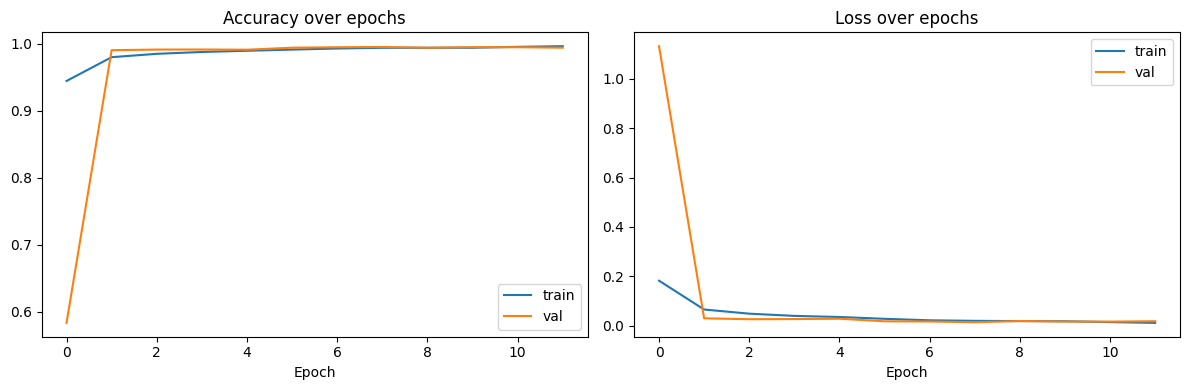

In [9]:
def plot_training_curves(history, out_dir):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["accuracy"], label="train")
    axes[0].plot(history.history["val_accuracy"], label="val")
    axes[0].set_title("Accuracy over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history.history["loss"], label="train")
    axes[1].plot(history.history["val_loss"], label="val")
    axes[1].set_title("Loss over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "training_curves.png"), dpi=150)
    plt.show()


plot_training_curves(history, OUT_DIR)

### **Evaluate: accuracy, precision, recall, F1, confusion matrix**

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       1.00      1.00      1.00      1010
           4       1.00      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



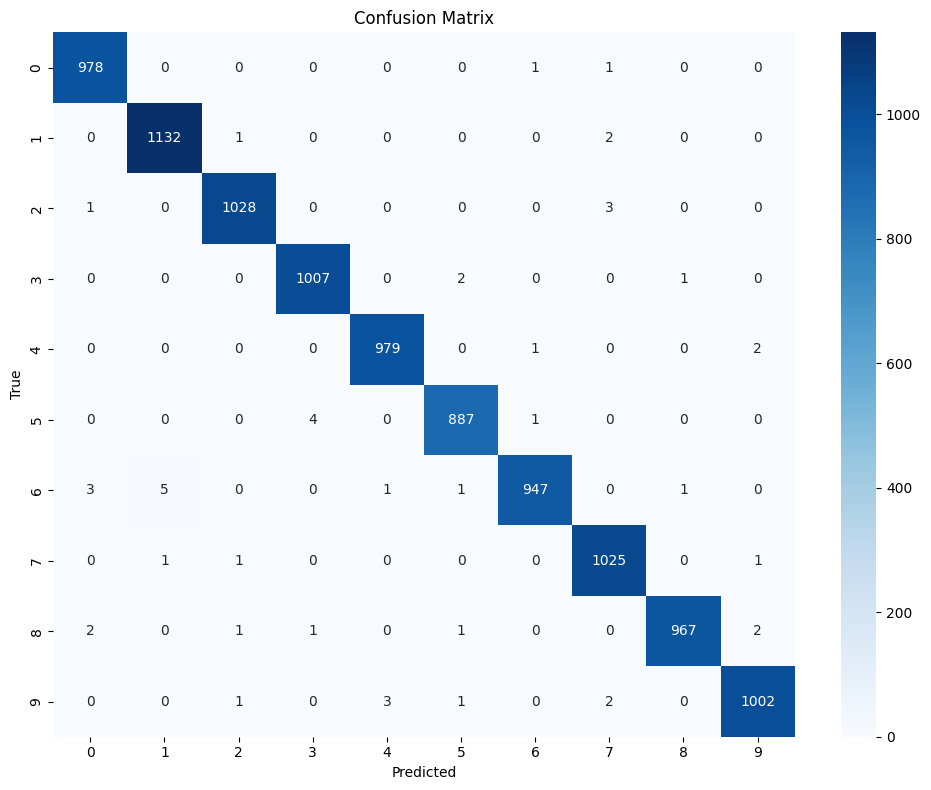


Final Test Accuracy: 0.9952
Final Test Loss:     0.0138


0.995199978351593

In [10]:
def evaluate_and_plot(model, x_test, y_test_cat, y_test_raw, class_names, out_dir):
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    report = classification_report(y_test_raw, y_pred, target_names=class_names)
    print("\nClassification Report:\n", report)
    with open(os.path.join(out_dir, "classification_report.txt"), "w") as f:
        f.write(report)

    cm = confusion_matrix(y_test_raw, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=len(class_names) <= 15, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "confusion_matrix.png"), dpi=150)
    plt.show()

    test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
    print(f"\nFinal Test Accuracy: {test_acc:.4f}")
    print(f"Final Test Loss:     {test_loss:.4f}")
    return test_acc


evaluate_and_plot(model, x_test_p, y_test_cat, y_test, class_names, OUT_DIR)

##  **Visualize sample predictions (correct = green, wrong = red)**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step


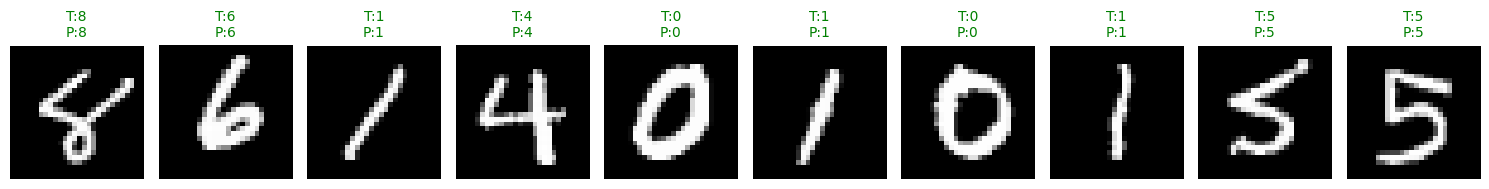

In [11]:
def show_sample_predictions(model, x_test, y_test_raw, class_names, out_dir, n=10):
    idx = np.random.choice(len(x_test), n, replace=False)
    preds = np.argmax(model.predict(x_test[idx]), axis=1)

    plt.figure(figsize=(15, 3))
    for i, j in enumerate(idx):
        plt.subplot(1, n, i + 1)
        plt.imshow(x_test[j].squeeze(), cmap="gray")
        true_label = class_names[y_test_raw[j]]
        pred_label = class_names[preds[i]]
        color = "green" if true_label == pred_label else "red"
        plt.title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "sample_predictions.png"), dpi=150)
    plt.show()


show_sample_predictions(model, x_test_p, y_test, class_names, OUT_DIR)

## **Save the trained model**

In [12]:
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")
print(f"Plots & reports saved to: {OUT_DIR}/")

Model saved to: handwriting_cnn.keras
Plots & reports saved to: outputs/


## **Predict on your own uploaded image**

Run this cell to upload an image from your computer and classify it with the trained model.

Saving New_digit.jpeg to New_digit.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


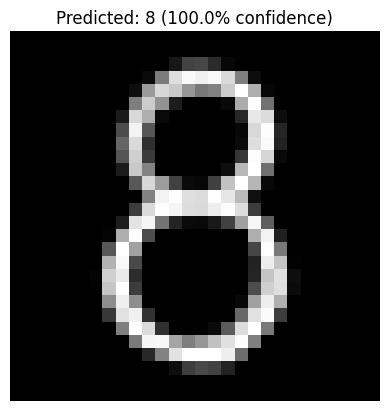

Top-3 predictions:
    8  -  100.00%
    6  -  0.00%
    3  -  0.00%


In [14]:
from google.colab import files
from PIL import Image

uploaded = files.upload()
image_path = list(uploaded.keys())[0]


def load_and_prepare_image(path, invert="auto"):
    img = Image.open(path).convert("L")
    img = img.resize((28, 28))
    arr = np.array(img).astype("float32")

    if invert == "auto" and arr.mean() > 127:
        arr = 255.0 - arr
    elif invert == "yes":
        arr = 255.0 - arr

    arr = arr / 255.0
    return arr.reshape(1, 28, 28, 1)


x = load_and_prepare_image(image_path)
probs = model.predict(x)[0]
pred_idx = int(np.argmax(probs))

plt.imshow(x.squeeze(), cmap="gray")
plt.title(f"Predicted: {class_names[pred_idx]} ({probs[pred_idx]:.1%} confidence)")
plt.axis("off")
plt.show()

print("Top-3 predictions:")
for i in np.argsort(probs)[-3:][::-1]:
    print(f"  {class_names[i]:>3}  -  {probs[i]:.2%}")

In [ ]:
# import shutil
# from google.colab import files

# shutil.make_archive("results", "zip", OUT_DIR)
# files.download("results.zip")
# files.download(MODEL_PATH)

## **Conclusion**

The Convolutional Neural Network (CNN) model was successfully trained on the **MNIST** dataset. The model achieved a **Final Test Accuracy of 0.9952** and a **Final Test Loss of 0.0138**. The classification report and confusion matrix also indicate excellent performance with high precision, recall, and F1-scores across all digit classes. The model is highly effective in recognizing handwritten digits (0-9).